# Vietnam Portfolio: Profitable Stock Selection, Risk Management, and Portfolio Composition

**Design choices:**

| Decision | Choice | Why |
|---|---|---|
| Modeling approach | Single shared LSTM trained on multiple tickers, predicting forward h-day return | DL is mandatory; one shared model > one model per ticker (more data, less overfit); predicting return (not price) is scale-free across tickers |
| Target | h-day forward log return | Stationary, comparable across stocks |
| Time-series split | Strict chronological: train (oldest 70%) → val (next 15%) → test (newest 15%); no shuffle | Required by the FAQ (Q4) |
| Cross-validation | Walk-forward (expanding-window) on the train+val portion | Required by FAQ (Q5) |
| Window | 30 trading days input → h=5 day forward return | One trading month is a common standard horizon for swing portfolios |
| Company filter | ≥ 504 trading days (~2 years) of clean history; HOSE/HNX/UPCOM allowed | Project FAQ Q10 suggests long-history companies; 504 days gives enough train+val+test |
| Profit score | Mean of model-predicted forward returns over the validation window | Direct readout of "expected profit" from the DL model |
| Risk score | Composite z-score of (realized volatility, max drawdown, downside deviation) over validation window | Three complementary risk facets used in finance |
| Portfolio weights | Risk-adjusted expected return, normalized; long-only, sum to 1 | Simple, transparent mean-variance-style allocation |


## 1. Setup, imports, and data paths

In [ ]:
# Google Drive Mount
from google.colab import drive
import shutil
from pathlib import Path

# Mount drive
drive.mount('/content/drive')

#  DATA MIGRATION — Drive to High-Speed Local Colab Storage
DRIVE_BASE_PATH = Path('/content/drive/MyDrive/deep-learning/DL4AI_Project_Data')

LOCAL_DATA_PATH = Path('/content/data')

def setup_clean_storage(drive_path: Path, local_path: Path):
    """Copies pre-filtered clean data directly to Colab local storage."""
    if drive_path.exists():
        if not local_path.exists():
            print(f"Copying clean data from {drive_path.name} to local storage...")
            shutil.copytree(drive_path, local_path)
            print("Copy complete.")
        else:
            print(f"Data already exists at {local_path}.")
    else:
        print(f"Error: Could not find {drive_path}. Check your Drive path.")

#  PATHS
VN_CLEAN_DRIVE   = DRIVE_BASE_PATH / "vnindex_clean"
VN_CLEAN_DIR     = LOCAL_DATA_PATH / "vietnam/vnindex_clean"

COMPANIES_CSV    = DRIVE_BASE_PATH / "companies.csv"
OVERVIEW_CSV     = DRIVE_BASE_PATH / "ticker-overview.csv"

MODEL_DIR        = Path("./models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

setup_clean_storage(VN_CLEAN_DRIVE, VN_CLEAN_DIR)

Mounted at /content/drive
Copying clean data from vnindex_clean to local storage...
Copy complete.


In [ ]:
# Standard imports
import os, glob, math, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# Hyperparameters (justified above)
WINDOW    = 30      # input lookback (≈ 1 trading month)
HORIZON   = 5       # forecast forward h-day return (≈ 1 trading week)
MIN_DAYS  = 504     # ≈ 2 years of history minimum per ticker
BATCH     = 256
EPOCHS    = 20
LR        = 1e-3

## 2. Load and filter Vietnam stock universe

We scan `vnindex_clean/` for per-ticker historical CSVs, keep only tickers with ≥ `MIN_DAYS` clean rows, and merge basic exchange/industry info from `companies.csv` and `ticker-overview.csv`.

In [ ]:
def load_ticker_history(csv_path: Path) -> pd.DataFrame:
    """Load one ticker's OHLCV file. Robust to the leading 'Unnamed: 0' index column."""
    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    df["TradingDate"] = pd.to_datetime(df["TradingDate"])
    df = df.sort_values("TradingDate").reset_index(drop=True)
    # Drop rows with non-positive prices (cleaning guard)
    df = df[(df[["Open","High","Low","Close"]] > 0).all(axis=1)].reset_index(drop=True)
    return df

def infer_ticker_from_filename(p: Path) -> str:
    """Files look like 'AAAVNINDEXHistory.csv' → ticker 'AAA'."""
    name = p.stem  # 'AAAVNINDEXHistory'
    if "VNINDEX" in name:
        return name.split("VNINDEX")[0]
    return name  # fallback

# Discover all per-ticker history files
hist_files = sorted(VN_CLEAN_DIR.glob("*History.csv"))
print(f"Found {len(hist_files)} history files.")

ticker_data = {}
for fp in hist_files:
    try:
        df = load_ticker_history(fp)
        if len(df) >= MIN_DAYS:
            ticker_data[infer_ticker_from_filename(fp)] = df
    except Exception as e:
        pass

print(f"Tickers retained (≥ {MIN_DAYS} days clean): {len(ticker_data)}")

Found 348 history files.
Tickers retained (≥ 504 days clean): 348


In [ ]:
# Merge companies metadata for context (industry, exchange) — used later for reporting
companies = pd.read_csv(COMPANIES_CSV).loc[:, lambda d: ~d.columns.str.startswith("Unnamed")]
overview  = pd.read_csv(OVERVIEW_CSV).loc[:, lambda d: ~d.columns.str.startswith("Unnamed")]
meta = companies.merge(
    overview[["ticker","exchange","industry","industryEn"]],
    on="ticker", how="left"
)
print(meta.head(3))

  ticker  group_code                                    company_name  \
0    VVS  UpcomIndex  Công ty Cổ phần Đầu tư Phát triển Máy Việt Nam   
1    XDC  UpcomIndex   Công ty TNHH MTV Xây dựng Công trình Tân Cảng   
2    HSV  UpcomIndex                Công ty Cổ phần Gang Thép Hà Nội   

               company_short_name exchange              industry  \
0  Đầu tư Phát triển Máy Việt Nam    UPCOM      Ô tô và phụ tùng   
1    Xây dựng Công trình Tân Cảng    UPCOM  Xây dựng và Vật liệu   
2                Gang Thép Hà Nội    UPCOM     Tài nguyên Cơ bản   

                 industryEn  
0       Automobiles & Parts  
1  Construction & Materials  
2           Basic Resources  


## 3. Common time axis & chronological split

To compare tickers fairly, we align everyone on the **intersection** of their date ranges, then carve a single chronological split:

- **Train**: oldest 70%
- **Val**:   next 15%   (used for portfolio scoring)
- **Test**:  newest 15% (held out, used for final out-of-sample evaluation)

In [ ]:
# Intersect on a common date range so train/val/test cut-points are identical for all tickers
all_dates = None
for t, df in ticker_data.items():
    s = set(df["TradingDate"])
    all_dates = s if all_dates is None else (all_dates & s)
common_dates = sorted(all_dates)
print(f"Common trading days across {len(ticker_data)} tickers: {len(common_dates)}")

# Re-index every ticker to the common axis
for t in list(ticker_data.keys()):
    df = ticker_data[t].set_index("TradingDate").loc[common_dates].reset_index()
    ticker_data[t] = df

# Chronological split indices
N = len(common_dates)
i_train_end = int(N * 0.70)
i_val_end   = int(N * 0.85)

train_dates = common_dates[:i_train_end]
val_dates   = common_dates[i_train_end:i_val_end]
test_dates  = common_dates[i_val_end:]
print(f"Train: {train_dates[0].date()} → {train_dates[-1].date()} ({len(train_dates)} days)")
print(f"Val  : {val_dates[0].date()} → {val_dates[-1].date()} ({len(val_dates)} days)")
print(f"Test : {test_dates[0].date()} → {test_dates[-1].date()} ({len(test_dates)} days)")

Common trading days across 348 tickers: 860
Train: 2019-02-26 → 2022-01-24 (602 days)
Val  : 2022-01-25 → 2022-08-19 (129 days)
Test : 2022-08-22 → 2023-02-28 (129 days)


## 4. Feature engineering & sample construction

**Inputs (per day, per ticker):** OHLC log returns + log volume change + 5-day RSI proxy + 10-day rolling volatility — six features that are stationary and scale-free.

**Target:** h-day forward log return  = `log(Close_{t+h} / Close_t)`.

We build supervised samples with a `WINDOW`-sized rolling lookback. Splits are based on the **last day of the input window** so no leakage.

In [ ]:
FEATURES = ["ret_o","ret_h","ret_l","ret_c","vol_chg","rsi5","vol10"]

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # Log returns
    for col, name in [("Open","ret_o"),("High","ret_h"),("Low","ret_l"),("Close","ret_c")]:
        out[name] = np.log(out[col] / out[col].shift(1))
    # Log volume change (clip to avoid -inf when volume=0)
    v = out["Volume"].replace(0, np.nan)
    out["vol_chg"] = np.log(v / v.shift(1))
    # 5-day RSI proxy = mean of positive / mean of |returns| (smoothed)
    r = out["ret_c"]
    gain = r.clip(lower=0).rolling(5).mean()
    abs_ = r.abs().rolling(5).mean()
    out["rsi5"] = (gain / abs_.replace(0, np.nan)).fillna(0.5)
    # 10-day rolling realized vol
    out["vol10"] = r.rolling(10).std().fillna(0.0)
    # Forward h-day log return target
    out["fwd_ret"] = np.log(out["Close"].shift(-HORIZON) / out["Close"])
    return out

# Build features for all tickers
feat_data = {t: build_features(df) for t, df in ticker_data.items()}

# Sanity check
sample_t = next(iter(feat_data))
print(f"Example features for {sample_t}:")
print(feat_data[sample_t][["TradingDate","Close"] + FEATURES + ["fwd_ret"]].tail())

Example features for AAA-:
    TradingDate   Close     ret_o     ret_h     ret_l     ret_c   vol_chg  \
855  2023-02-22  8600.0 -0.024973 -0.032100 -0.024153 -0.028655 -0.022983   
856  2023-02-23  8830.0 -0.011561 -0.006772 -0.010533  0.026393 -0.413198   
857  2023-02-24  8710.0  0.026393  0.032315  0.024406 -0.013683 -0.114372   
858  2023-02-27  8700.0 -0.014832 -0.003295 -0.006912 -0.001149  0.243821   
859  2023-02-28  8690.0  0.014832 -0.023373  0.001155 -0.001150 -0.761806   

         rsi5     vol10  fwd_ret  
855  0.716283  0.040181      NaN  
856  0.748086  0.038470      NaN  
857  0.672618  0.037443      NaN  
858  0.360242  0.026733      NaN  
859  0.371572  0.026622      NaN  


In [ ]:
def make_samples(df: pd.DataFrame, ticker: str):
    """Slide a WINDOW over the ticker, label each window with its split bucket
    (train/val/test) by the LAST day of the window."""
    X, y, dates, tags, tickers = [], [], [], [], []
    arr = df[FEATURES].values
    tgt = df["fwd_ret"].values
    dts = df["TradingDate"].values
    for i in range(WINDOW, len(df) - HORIZON):
        x = arr[i - WINDOW : i]
        yt = tgt[i - 1]  # target labelled at end of window (same row uses Close_t as anchor)
        if np.isnan(x).any() or np.isnan(yt):
            continue
        last_day = dts[i - 1]
        if last_day <= np.datetime64(train_dates[-1]):
            tag = "train"
        elif last_day <= np.datetime64(val_dates[-1]):
            tag = "val"
        else:
            tag = "test"
        X.append(x); y.append(yt); dates.append(last_day); tags.append(tag); tickers.append(ticker)
    return X, y, dates, tags, tickers

X_all, y_all, d_all, tag_all, tkr_all = [], [], [], [], []
for t, df in feat_data.items():
    X, y, d, tg, tk = make_samples(df, t)
    X_all += X; y_all += y; d_all += d; tag_all += tg; tkr_all += tk

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.float32)
d_all = np.array(d_all)
tag_all = np.array(tag_all)
tkr_all = np.array(tkr_all)
print(f"Total samples: {len(X_all)}  shape={X_all.shape}")
print(f"  train={(tag_all=='train').sum()}  val={(tag_all=='val').sum()}  test={(tag_all=='test').sum()}")

Total samples: 226030  shape=(226030, 30, 7)
  train=153250  val=38614  test=34166


In [ ]:
# Per-feature standardisation using TRAIN-ONLY statistics (no leakage)
train_mask = tag_all == "train"
mu = X_all[train_mask].reshape(-1, X_all.shape[-1]).mean(axis=0)
sd = X_all[train_mask].reshape(-1, X_all.shape[-1]).std(axis=0) + 1e-8
X_all = (X_all - mu) / sd

# Also clip target to reduce influence of extreme outliers (limit ±20% over h days)
y_all = np.clip(y_all, -0.20, 0.20)

X_train, y_train = X_all[tag_all == "train"], y_all[tag_all == "train"]
X_val,   y_val   = X_all[tag_all == "val"],   y_all[tag_all == "val"]
X_test,  y_test  = X_all[tag_all == "test"],  y_all[tag_all == "test"]
print(X_train.shape, X_val.shape, X_test.shape)

(153250, 30, 7) (38614, 30, 7) (34166, 30, 7)


## 5. Walk-forward (expanding-window) cross-validation

Per the project FAQ (Q5), random k-fold is invalid for time-series. We use **3 expanding-window folds** on the training portion to verify model stability before training the final model on full train+val.

In [ ]:
def walk_forward_cv(X, y, n_folds=3):
    """Yield (train_idx, val_idx) pairs with expanding train and contiguous val."""
    N = len(X)
    fold_size = N // (n_folds + 1)
    for k in range(1, n_folds + 1):
        tr_end = k * fold_size
        va_end = (k + 1) * fold_size
        yield np.arange(0, tr_end), np.arange(tr_end, va_end)

def build_lstm(input_shape, lr=LR):
    inp = Input(shape=input_shape)
    x = LSTM(64, return_sequences=True)(inp)
    x = Dropout(0.2)(x)
    x = LSTM(32)(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation="relu")(x)
    out = Dense(1)(x)  # regression: forward return
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return m

# Sort training samples by date so walk-forward respects chronology across tickers
order = np.argsort(d_all[tag_all == "train"])
X_tr_s = X_train[order]
y_tr_s = y_train[order]

cv_scores = []
for k, (tr_idx, va_idx) in enumerate(walk_forward_cv(X_tr_s, y_tr_s, n_folds=3), 1):
    tf.keras.backend.clear_session()
    m = build_lstm(X_train.shape[1:])
    m.fit(X_tr_s[tr_idx], y_tr_s[tr_idx],
          validation_data=(X_tr_s[va_idx], y_tr_s[va_idx]),
          epochs=8, batch_size=BATCH, verbose=0,
          callbacks=[EarlyStopping(patience=2, restore_best_weights=True)])
    val_mae = m.evaluate(X_tr_s[va_idx], y_tr_s[va_idx], verbose=0)[1]
    cv_scores.append(val_mae)
    print(f"Fold {k}: val MAE = {val_mae:.5f}")
print(f"CV mean MAE = {np.mean(cv_scores):.5f}  std = {np.std(cv_scores):.5f}")

Fold 1: val MAE = 0.04970
Fold 2: val MAE = 0.05219
Fold 3: val MAE = 0.05207
CV mean MAE = 0.05132  std = 0.00115


## 6. Train the LSTM on train + val

Per task notes, Task 4 needs a **train/val split** for the portfolio decisions; the test set is reserved as a future-period out-of-sample check. We train the final model on `train` only, then use its **validation-window predictions** to score profitability and risk per ticker (the prudent choice — using held-out predictions, not training-fit ones).

In [ ]:
tf.keras.backend.clear_session()
model = build_lstm(X_train.shape[1:])
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True, monitor="val_loss")],
    verbose=2,
)
model.save(MODEL_DIR / "task4_lstm.keras")

Epoch 1/20
599/599 - 8s - 13ms/step - loss: 0.0043 - mae: 0.0463 - val_loss: 0.0060 - val_mae: 0.0565
Epoch 2/20
599/599 - 7s - 12ms/step - loss: 0.0042 - mae: 0.0457 - val_loss: 0.0061 - val_mae: 0.0571
Epoch 3/20
599/599 - 5s - 9ms/step - loss: 0.0041 - mae: 0.0455 - val_loss: 0.0061 - val_mae: 0.0574
Epoch 4/20
599/599 - 7s - 11ms/step - loss: 0.0041 - mae: 0.0452 - val_loss: 0.0063 - val_mae: 0.0586
Epoch 5/20
599/599 - 9s - 15ms/step - loss: 0.0040 - mae: 0.0448 - val_loss: 0.0065 - val_mae: 0.0595


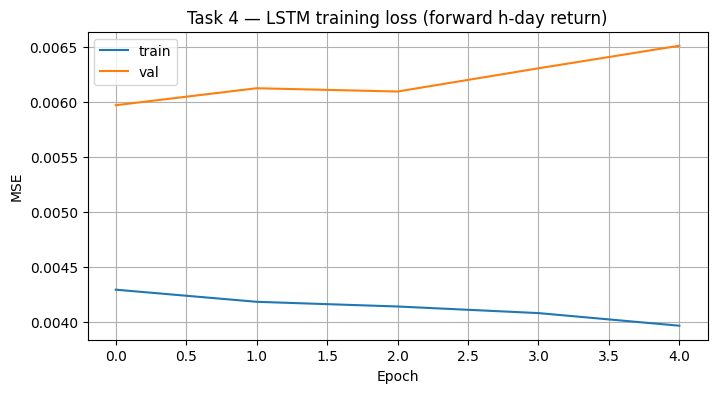

In [ ]:
# Loss curves
plt.figure(figsize=(8,4))
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.title("Task 4 — LSTM training loss (forward h-day return)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.grid(); plt.show()

## Task 4.1 — Profitable stock selection

**Methodology:**
1. Predict forward h-day return for every (ticker, day) sample in the **validation window**.
2. For each ticker, compute the **mean predicted return** as its profitability score.
3. Annualize ≈ `mean_h_day_return × (252 / HORIZON)` for human-readable reporting.
4. Rank tickers; the top decile (or top-K) is the **profitable list**.

In [ ]:
# Predict on the validation slice
val_mask = tag_all == "val"
X_val_  = X_all[val_mask]
y_pred_val = model.predict(X_val_, verbose=0).ravel()
tkr_val  = tkr_all[val_mask]
date_val = d_all[val_mask]

# Per-ticker mean predicted h-day return (profitability score)
df_val = pd.DataFrame({"ticker": tkr_val, "date": date_val, "pred": y_pred_val})
profit_score = (
    df_val.groupby("ticker")["pred"]
          .mean()
          .rename("profit_score_h")
          .reset_index()
)
profit_score["annualized_return_pct"] = (
    profit_score["profit_score_h"] * (252.0 / HORIZON) * 100.0
)
profit_score = profit_score.sort_values("profit_score_h", ascending=False).reset_index(drop=True)
print(profit_score.head(15))

   ticker  profit_score_h  annualized_return_pct
0    QCG-        0.015695              79.100777
1    DCM-        0.015224              76.731125
2    DIG-        0.015212              76.670471
3    DXG-        0.015136              76.286057
4    ASM-        0.014281              71.976089
5    GEX-        0.014250              71.819267
6    SCR-        0.014169              71.409973
7    DPG-        0.014150              71.317764
8    HAG-        0.014113              71.128479
9    DLG-        0.013994              70.532158
10   NBB-        0.013973              70.425682
11   JVC-        0.013761              69.357689
12   ITA-        0.013383              67.450279
13   DPM-        0.013303              67.048599
14   QBS-        0.013291              66.989120


In [ ]:
TOP_K = max(10, int(0.10 * len(profit_score)))   # top decile, at least 10
profitable_list = profit_score.head(TOP_K)["ticker"].tolist()
print(f"\nProfitable list (top {TOP_K} of {len(profit_score)}):")
print(profitable_list)


Profitable list (top 33 of 333):
['QCG-', 'DCM-', 'DIG-', 'DXG-', 'ASM-', 'GEX-', 'SCR-', 'DPG-', 'HAG-', 'DLG-', 'NBB-', 'JVC-', 'ITA-', 'DPM-', 'QBS-', 'LDG-', 'HAR-', 'BCG-', 'HQC-', 'VGC-', 'HHS-', 'LCG-', 'CMX-', 'FCN-', 'FTS-', 'VIX-', 'LGL-', 'HDC-', 'DGW-', 'VOS-', 'IDI-', 'CTI-', 'TTB-']


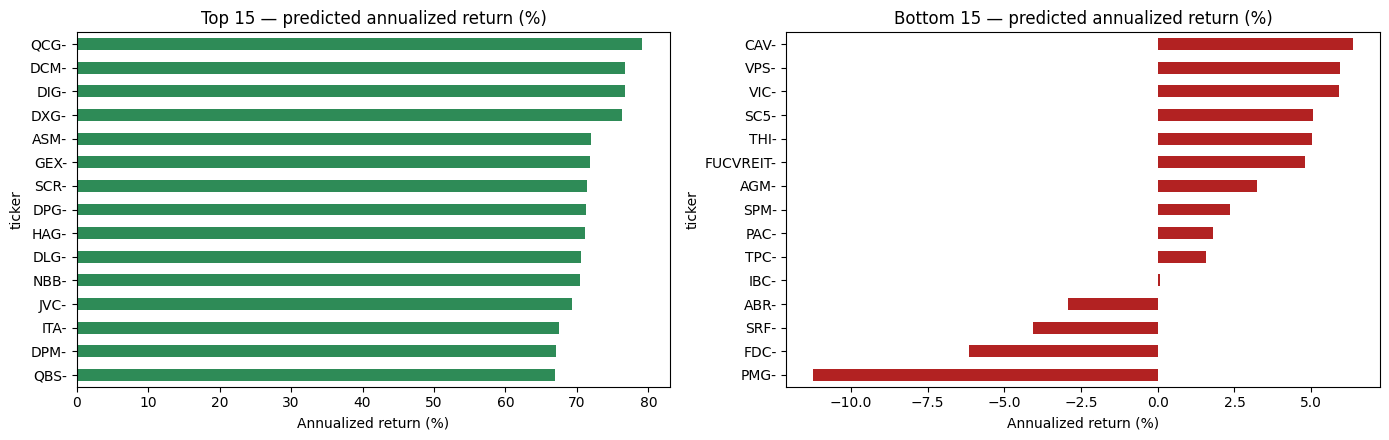

In [ ]:
# Visualise top vs bottom 15
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
profit_score.head(15).plot.barh(x="ticker", y="annualized_return_pct",
    ax=ax[0], color="seagreen", legend=False)
ax[0].invert_yaxis(); ax[0].set_title("Top 15 — predicted annualized return (%)")
ax[0].set_xlabel("Annualized return (%)")

profit_score.tail(15).plot.barh(x="ticker", y="annualized_return_pct",
    ax=ax[1], color="firebrick", legend=False)
ax[1].invert_yaxis(); ax[1].set_title("Bottom 15 — predicted annualized return (%)")
ax[1].set_xlabel("Annualized return (%)")
plt.tight_layout(); plt.show()

## Task 4.2 — Risk management

**Methodology — composite risk score from three complementary facets** computed on each ticker's
*realized* daily Close returns over the **validation window**:

| Risk facet | Why |
|---|---|
| **Realized volatility** (std of daily log returns) | Standard market risk |
| **Maximum drawdown** | Worst peak-to-trough drop — captures tail loss / "ruin" risk |
| **Downside deviation** (std of negative returns only) | Asymmetric — penalises only losses, used in Sortino ratio |

We z-score each facet on the validation universe and average → a unitless **risk score**. Tickers above the top quartile of risk score (worst 25%) are flagged for **exclusion**.

In [ ]:
def realized_metrics_validation(ticker: str) -> dict:
    df = feat_data[ticker]
    sub = df[df["TradingDate"].isin(val_dates)].copy()
    r = sub["ret_c"].dropna().values
    if len(r) < 10:
        return {"vol": np.nan, "max_dd": np.nan, "dd_dev": np.nan}
    # Realised vol (annualised)
    vol = r.std() * math.sqrt(252)
    # Max drawdown on cumulative returns
    cum = np.exp(np.cumsum(r))
    peaks = np.maximum.accumulate(cum)
    dd = (cum / peaks) - 1.0
    max_dd = -dd.min()  # report as positive magnitude
    # Downside deviation
    neg = r[r < 0]
    dd_dev = neg.std() * math.sqrt(252) if len(neg) > 1 else 0.0
    return {"vol": vol, "max_dd": max_dd, "dd_dev": dd_dev}

risk_rows = []
for t in feat_data.keys():
    m = realized_metrics_validation(t)
    m["ticker"] = t
    risk_rows.append(m)
risk_df = pd.DataFrame(risk_rows).dropna()

# Z-score each facet, then average
for c in ["vol","max_dd","dd_dev"]:
    risk_df[c + "_z"] = (risk_df[c] - risk_df[c].mean()) / (risk_df[c].std() + 1e-8)
risk_df["risk_score"] = risk_df[["vol_z","max_dd_z","dd_dev_z"]].mean(axis=1)
risk_df = risk_df.sort_values("risk_score", ascending=False).reset_index(drop=True)

print("Top 10 RISKIEST tickers (high risk_score = avoid):")
print(risk_df.head(10)[["ticker","vol","max_dd","dd_dev","risk_score"]])

Top 10 RISKIEST tickers (high risk_score = avoid):
  ticker       vol    max_dd    dd_dev  risk_score
0   VFG-  0.948354  0.302284  0.783321    2.726197
1   TGG-  1.001672  0.853289  0.414070    2.344166
2   PTC-  0.965075  0.807872  0.376741    2.018885
3   DIG-  0.822960  0.703384  0.416795    1.672411
4   CIG-  0.785528  0.721053  0.406845    1.581324
5   TSC-  0.769276  0.727387  0.411529    1.577133
6   LDG-  0.798344  0.682304  0.404029    1.523719
7   NVT-  0.790461  0.669753  0.401013    1.469510
8   VRC-  0.701712  0.745152  0.410622    1.457492
9   JVC-  0.764171  0.687732  0.400854    1.444954


Excluding 87 risky tickers (top quartile, risk_score ≥ 0.73)


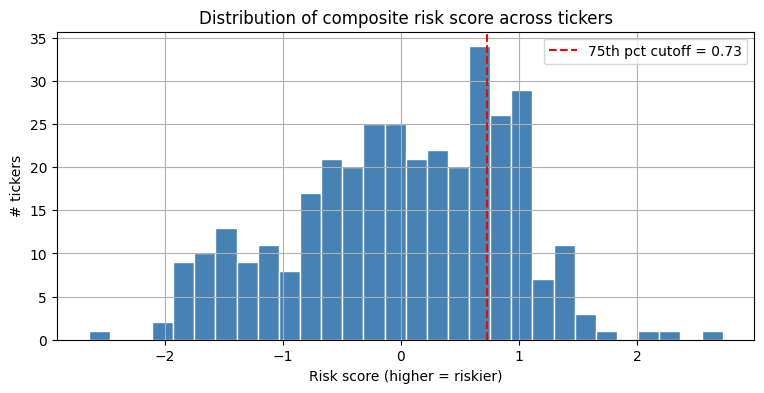

In [ ]:
# Exclude the top quartile risk tickers
RISK_CUTOFF = risk_df["risk_score"].quantile(0.75)
excluded = risk_df[risk_df["risk_score"] >= RISK_CUTOFF]["ticker"].tolist()
print(f"Excluding {len(excluded)} risky tickers (top quartile, risk_score ≥ {RISK_CUTOFF:.2f})")

# Visualise the risk distribution
plt.figure(figsize=(9,4))
plt.hist(risk_df["risk_score"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(RISK_CUTOFF, color="red", linestyle="--", label=f"75th pct cutoff = {RISK_CUTOFF:.2f}")
plt.title("Distribution of composite risk score across tickers")
plt.xlabel("Risk score (higher = riskier)"); plt.ylabel("# tickers"); plt.legend(); plt.grid(); plt.show()

## Task 4.3 — Portfolio composition

**Strategy.** Combine the profitability model (Task 4.1) with the risk model (Task 4.2):

1. **Universe** = all tickers **NOT** in the excluded (risky) set.
2. From this universe, keep tickers with **positive predicted return**.
3. Weight by **risk-adjusted expected return** (a Sharpe-like quantity):

    `score_i = max(0, profit_score_h_i) / (vol_i + ε)`

4. Long-only weights: `w_i = score_i / Σ score_i`. (No leverage, no shorts.)
5. Cap the portfolio at the **top 20** to avoid over-fragmentation.

Produce **two profiles**:

- **Risk-taking** — keep all positive-return tickers (excluding risky); weight by score.
- **Prudent** — additionally drop tickers above the **median** risk score (i.e., keep low-half risk only).

In [ ]:
# Merge profit + risk into a single decision table
decision = profit_score.merge(risk_df[["ticker","vol","risk_score"]], on="ticker", how="inner")

def build_portfolio(table: pd.DataFrame, max_holdings: int = 20, label: str = "") -> pd.DataFrame:
    df = table[table["profit_score_h"] > 0].copy()
    df["score"] = df["profit_score_h"] / (df["vol"] + 1e-6)
    df = df.sort_values("score", ascending=False).head(max_holdings)
    if df.empty:
        print(f"[{label}] No positive-return tickers — empty portfolio.")
        return df
    df["weight"] = df["score"] / df["score"].sum()
    return df.reset_index(drop=True)

# Risk-taking portfolio: drop only top-quartile risky
rt_universe = decision[~decision["ticker"].isin(excluded)]
risk_taking = build_portfolio(rt_universe, max_holdings=20, label="risk-taking")

# Prudent portfolio: drop top-quartile risky AND stay below median risk
median_risk = decision["risk_score"].median()
prudent_universe = decision[
    (~decision["ticker"].isin(excluded)) &
    (decision["risk_score"] <= median_risk)
]
prudent = build_portfolio(prudent_universe, max_holdings=20, label="prudent")

print("=== Risk-taking portfolio ===")
print(risk_taking[["ticker","annualized_return_pct","vol","risk_score","weight"]].round(4))
print(f"\nTotal weight: {risk_taking['weight'].sum():.4f}")
print("\n=== Prudent portfolio ===")
print(prudent[["ticker","annualized_return_pct","vol","risk_score","weight"]].round(4))
print(f"\nTotal weight: {prudent['weight'].sum():.4f}")

=== Risk-taking portfolio ===
   ticker  annualized_return_pct     vol  risk_score  weight
0    KOS-              36.029598  0.1842     -1.8872  0.0837
1    FIR-              36.307800  0.2824     -1.6396  0.0550
2    CTI-              60.214100  0.4903      0.4085  0.0526
3    CDC-              28.966499  0.2405     -1.7612  0.0515
4    HII-              54.684502  0.4644      0.3639  0.0504
5    ITD-              58.331402  0.4980      0.1470  0.0501
6    HHS-              63.665199  0.5554      0.7257  0.0490
7    NLG-              53.422501  0.4767     -0.0454  0.0480
8    PHR-              55.147499  0.4932      0.0958  0.0478
9    HAG-              71.128502  0.6385      0.7307  0.0477
10   ELC-              59.860901  0.5420      0.6494  0.0473
11   PHC-              51.439602  0.4661      0.3424  0.0472
12   TCH-              55.014801  0.5009      0.4306  0.0470
13   NTL-              40.817200  0.3719     -0.5403  0.0470
14   GVR-              52.558998  0.4793      0.1601  0

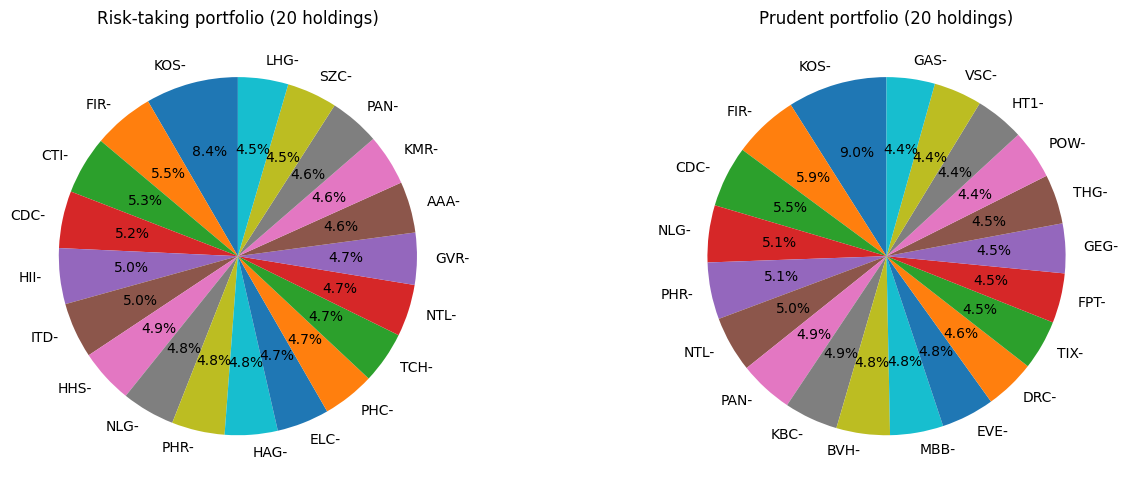

In [ ]:
# Visualise allocations
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
if not risk_taking.empty:
    ax[0].pie(risk_taking["weight"], labels=risk_taking["ticker"], autopct="%1.1f%%", startangle=90)
    ax[0].set_title(f"Risk-taking portfolio ({len(risk_taking)} holdings)")
if not prudent.empty:
    ax[1].pie(prudent["weight"], labels=prudent["ticker"], autopct="%1.1f%%", startangle=90)
    ax[1].set_title(f"Prudent portfolio ({len(prudent)} holdings)")
plt.tight_layout(); plt.show()

## 7. Out-of-sample evaluation on the test window

Sanity check: how do the two portfolios actually perform on the **test** period (newest 15%, never seen during training or scoring)? We compute realised cumulative return, annualised return, annualised volatility, Sharpe ratio, and max drawdown — and compare to an equal-weight benchmark of the entire eligible universe.

In [ ]:
def daily_returns_for_ticker(ticker: str, dates: list) -> pd.Series:
    df = feat_data[ticker]
    sub = df[df["TradingDate"].isin(dates)][["TradingDate","ret_c"]]
    return sub.set_index("TradingDate")["ret_c"]

def portfolio_test_returns(portfolio: pd.DataFrame) -> pd.Series:
    if portfolio.empty:
        return pd.Series(dtype=float)
    rets = pd.DataFrame({
        t: daily_returns_for_ticker(t, test_dates)
        for t in portfolio["ticker"]
    }).dropna(how="all")
    w = portfolio.set_index("ticker")["weight"].reindex(rets.columns).fillna(0).values
    return rets.fillna(0).values @ w  # ndarray of daily portfolio log-returns

def perf_stats(daily_log_rets) -> dict:
    if len(daily_log_rets) == 0:
        return {}
    r = np.asarray(daily_log_rets, dtype=float)
    cum = np.exp(np.cumsum(r))
    ann_ret = r.mean() * 252
    ann_vol = r.std()  * math.sqrt(252)
    sharpe  = ann_ret / (ann_vol + 1e-8)
    peaks   = np.maximum.accumulate(cum)
    max_dd  = (cum / peaks - 1).min()
    return {
        "cum_return_pct": (cum[-1] - 1) * 100,
        "ann_return_pct": ann_ret * 100,
        "ann_vol_pct":    ann_vol * 100,
        "sharpe":         sharpe,
        "max_drawdown_pct": max_dd * 100,
    }

# Benchmark = equal-weight all eligible (non-excluded) tickers
eligible = [t for t in feat_data.keys() if t not in excluded]
bench_pf = pd.DataFrame({"ticker": eligible, "weight": 1.0 / len(eligible)})

rt_r    = portfolio_test_returns(risk_taking)
prud_r  = portfolio_test_returns(prudent)
bench_r = portfolio_test_returns(bench_pf)

results = pd.DataFrame({
    "Risk-taking": perf_stats(rt_r),
    "Prudent":     perf_stats(prud_r),
    "Equal-weight benchmark": perf_stats(bench_r),
}).T.round(2)
print(results)

                        cum_return_pct  ann_return_pct  ann_vol_pct  sharpe  \
Risk-taking                     -26.59          -60.38        36.23   -1.67   
Prudent                         -16.83          -35.99        27.88   -1.29   
Equal-weight benchmark          -22.15          -48.92        21.37   -2.29   

                        max_drawdown_pct  
Risk-taking                       -43.97  
Prudent                           -33.17  
Equal-weight benchmark            -33.88  


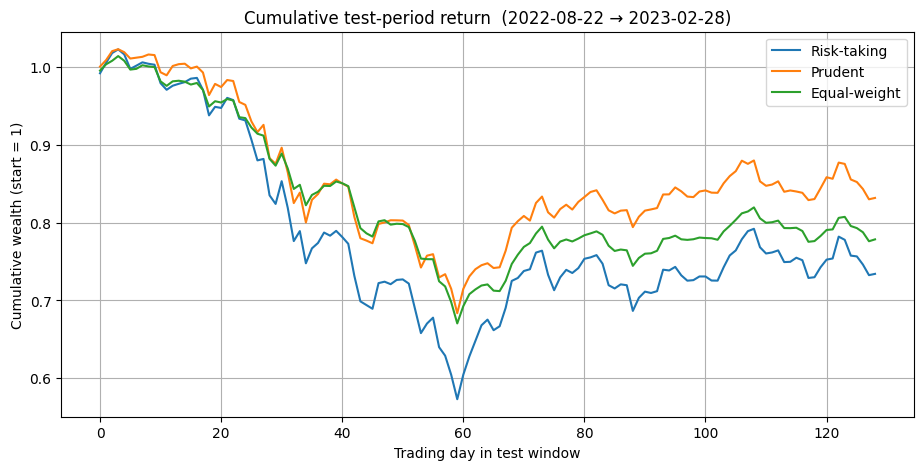

In [ ]:
# Cumulative-return curves on the test window
plt.figure(figsize=(11, 5))
for name, r in [("Risk-taking", rt_r), ("Prudent", prud_r), ("Equal-weight", bench_r)]:
    if len(r) == 0: continue
    cum = np.exp(np.cumsum(r))
    plt.plot(cum, label=name)
plt.title(f"Cumulative test-period return  ({test_dates[0].date()} → {test_dates[-1].date()})")
plt.xlabel("Trading day in test window"); plt.ylabel("Cumulative wealth (start = 1)")
plt.legend(); plt.grid(); plt.show()